In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy
# create an alias so “numpy._core.numeric” points to the real module
sys.modules['numpy._core.numeric'] = numpy.core.numeric
import pickle 
import ast
from collections.abc import Iterable
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

#import the modules for analyzing the results of the k-path search
from Path_Analytics import *


Goal: Create a set of analytics functions for the output of identified paths 
-
0) create a binary matrix of rows of paths and columns of drugs 
1) Distribution of drugs in each successful path across all conversions
2) Total number of successful paths for each conversion 
3) Unsupervised clustering for each conversion 
    - redundancy - total paths for each cluster 
    - uniqueness - total number of clusters per conversion 

In [13]:
#read in the pickle file 
with open('search_results_hpc_k15_steps7.pkl', 'rb') as f:
    df = pickle.load(f)
    
print(df['covered_threshold'].value_counts())
#filter down to only those that were successful
df = df[df['covered_threshold']==True]
df.columns

covered_threshold
False    12415
True      9764
Name: count, dtype: int64


Index(['search_id', 'type_of_search', 'n_steps', 'k', 'starting_cl',
       'target_cl', 'starting_position', 'target_position',
       'starting_distance', 'target_radius', 'step', 'path_type',
       'is_best_at_step', 'is_success', 'covered_threshold', 'end_position',
       'path', 'genes_targeted', 'cell_path', 'final_distance'],
      dtype='object')

covered_threshold
False    12415
True      9764
Name: count, dtype: int64


/Users/jbezney/Documents/GitHub/RL_single_cell/analysis/Path_Analytics.py:261: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: 1 if x > 0 else 0)
/Users/jbezney/Documents/GitHub/RL_single_cell/analysis/Path_Analytics.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


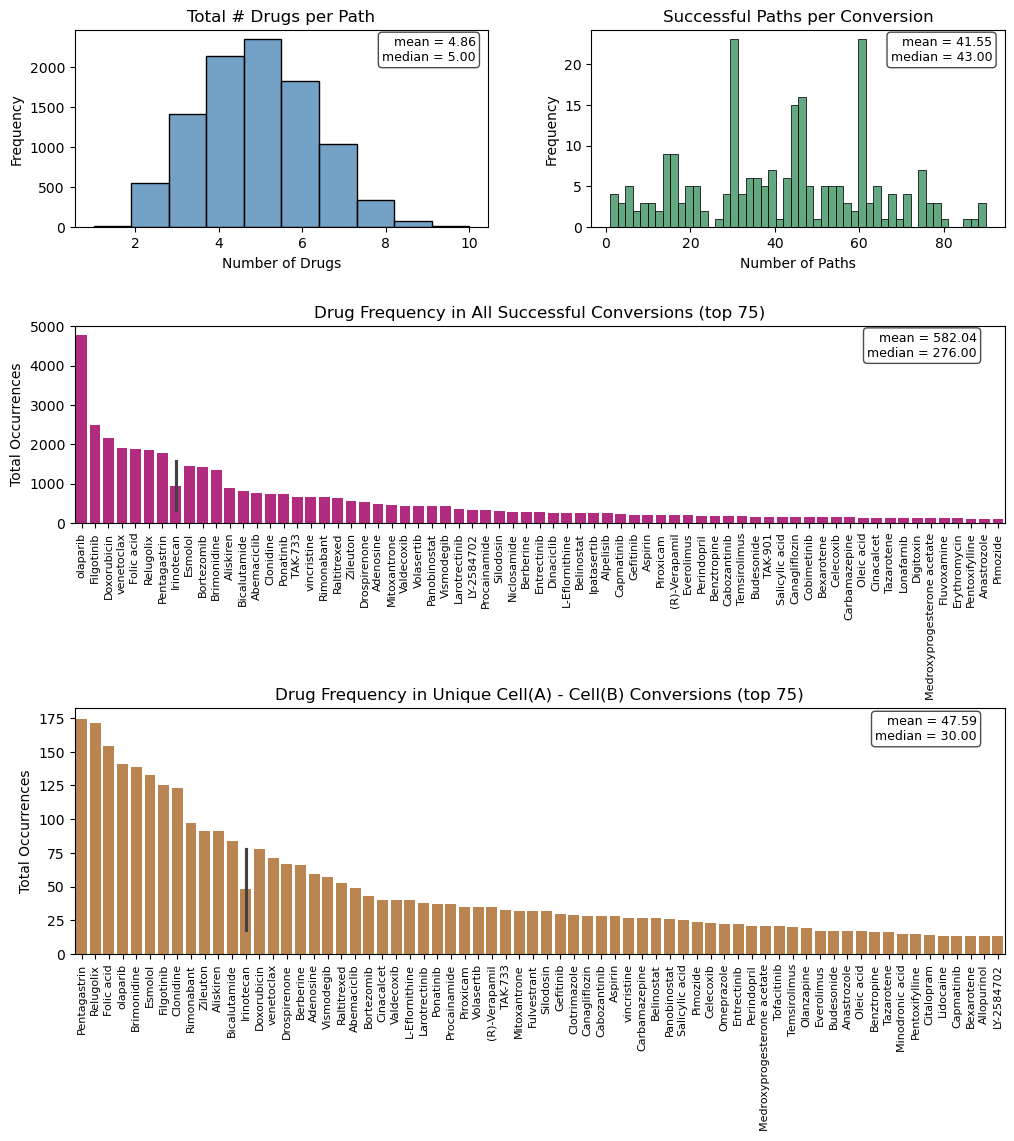

In [8]:
#create the binary drug matrix for each conversion 
drug_matrix = build_conversion_drug_matrix(df)

#plot initial QC for the drug matrix - global metrics
fig, axes = plot_path_and_conversion_stats(drug_matrix, 
                                    figsize=(12,12), 
                                    bins_drugs=10, 
                                    bins_conv=50,
                                    top_n=75,
                                    show=True)



#implement nearest neighbor and TSNE and UMAP

Jaccard Distance Threshold with Heirarchical clustering
-
option: Try different similarity parameters to ensure robust clustering

Meaning:
- 0.1 - 0.3 = Only paths with almost identical drug sets merge.
- 0.4 - 0.6 = Paths must share a fair proportion of drugs; moderate strictness
- 0.7 - 0.9 = Paths that share just a handful of drugs can end up together; coarse granularity
- 0.9 - 1.0 = Nearly everything collapses into one cluster (unless totally disjoint)

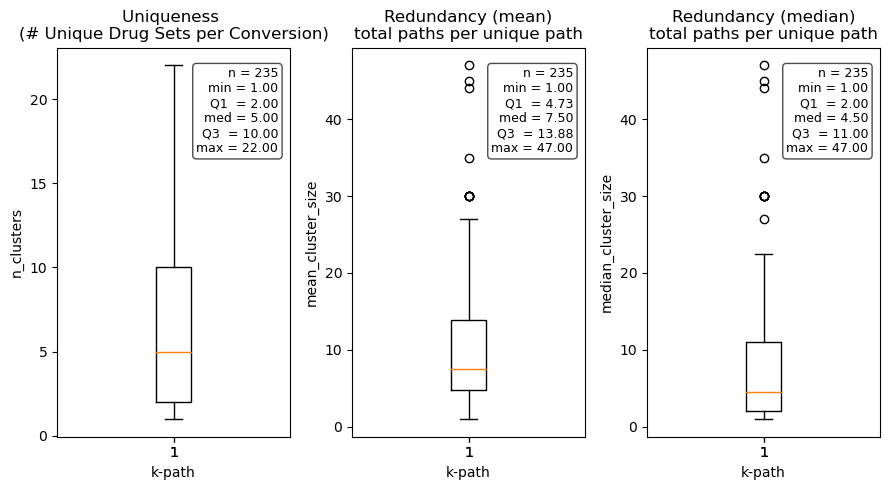

In [9]:
#now we can unsupervised cluster the conversions based on the drug matrix 
summary, detailed = cluster_all_conversions(
    drug_matrix,
    metric="jaccard",
    distance_threshold=0.5,
)

#plot the summary of the clustering results
fig, axes = plot_cluster_summary(
    summary,
    x_label="k-path",
    figsize=(9, 5),
    show=True
)

Updated k-means search and probabilistic search
-

In [26]:
#read in the pickle file 
with open('../data_and_models/search_results_tree_k4_n5.pkl', 'rb') as f:
    df = pickle.load(f)
    
print(df['covered_threshold'].value_counts())
#filter down to only those that were successful
df = df[df['covered_threshold']==True]
df['path'] = df['drug_sequence']

covered_threshold
True     66513
False    10528
Name: count, dtype: int64


In [31]:
df.columns

Index(['search_id', 'type_of_search', 'n_steps', 'k', 'n_paths', 'beta',
       'blend', 'threshold', 'starting_cl', 'target_cl', 'starting_position',
       'target_position', 'starting_distance', 'target_radius', 'step',
       'path_type', 'is_best_at_step', 'is_success', 'covered_threshold',
       'end_position', 'drug_sequence', 'genes_targeted', 'cell_path',
       'final_distance', 'path'],
      dtype='object')

In [33]:
df['percent_complete'] = (df['starting_distance'] - df['final_distance'])/ df['starting_distance']
df['percent_complete'].describe()

count    66513.000000
mean         0.458195
std          0.046092
min          0.400001
25%          0.419887
50%          0.446284
75%          0.489653
max          0.629979
Name: percent_complete, dtype: float64

/Users/jbezney/Documents/GitHub/RL_single_cell/analysis/Path_Analytics.py:261: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: 1 if x > 0 else 0)
/Users/jbezney/Documents/GitHub/RL_single_cell/analysis/Path_Analytics.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


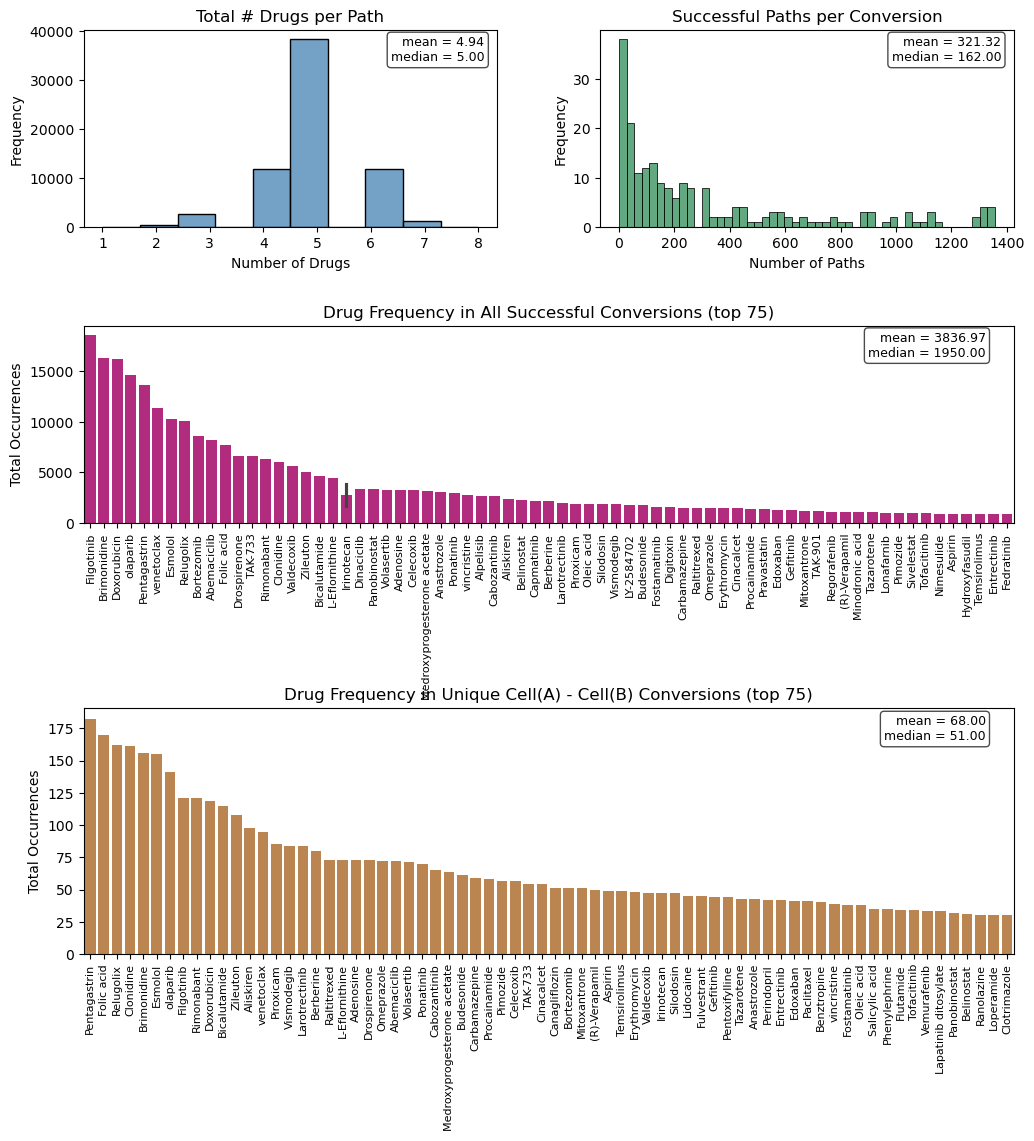

In [21]:
#create the binary drug matrix for each conversion 
drug_matrix = build_conversion_drug_matrix(df)

#plot initial QC for the drug matrix - global metrics
fig, axes = plot_path_and_conversion_stats(drug_matrix, 
                                    figsize=(12,12), 
                                    bins_drugs=10, 
                                    bins_conv=50,
                                    top_n=75,
                                    show=True)

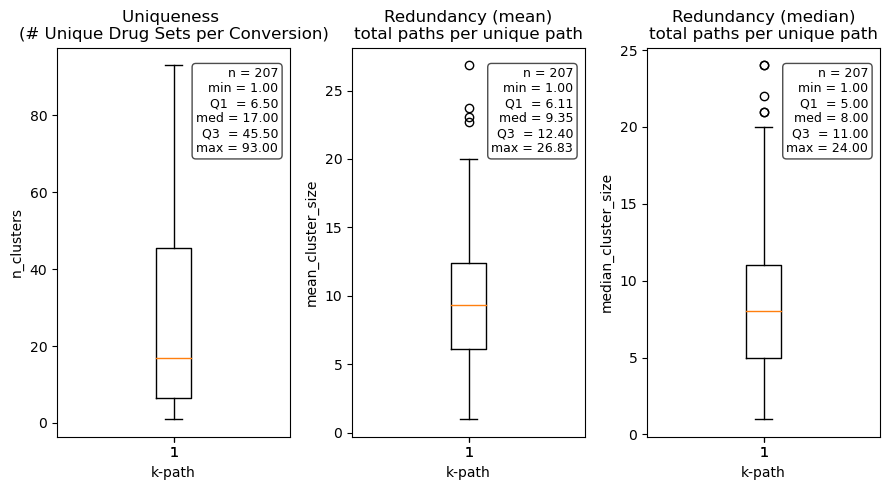

In [22]:
#now we can unsupervised cluster the conversions based on the drug matrix 
summary, detailed = cluster_all_conversions(
    drug_matrix,
    metric="jaccard",
    distance_threshold=0.5,
)

#plot the summary of the clustering results
fig, axes = plot_cluster_summary(
    summary,
    x_label="k-path",
    figsize=(9, 5),
    show=True
)

probabilistic
-

In [34]:
#read in the pickle file 
with open('../data_and_models/probabilistic_search_results_paths300_steps5_b1.0_blend2_thr0.4.pkl', 'rb') as f:
    df = pickle.load(f)
    
print(df['covered_threshold'].value_counts())
#filter down to only those that were successful
df = df[df['covered_threshold']==True]
df['path'] = df['drug_sequence']

covered_threshold
False    11069
True      2880
Name: count, dtype: int64


In [35]:
df['percent_complete'] = (df['starting_distance'] - df['final_distance'])/ df['starting_distance']
df['percent_complete'].describe()

count    2880.000000
mean        0.429832
std         0.026261
min         0.400007
25%         0.410203
50%         0.422759
75%         0.441945
max         0.577906
Name: percent_complete, dtype: float64

/Users/jbezney/Documents/GitHub/RL_single_cell/analysis/Path_Analytics.py:261: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: 1 if x > 0 else 0)
/Users/jbezney/Documents/GitHub/RL_single_cell/analysis/Path_Analytics.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


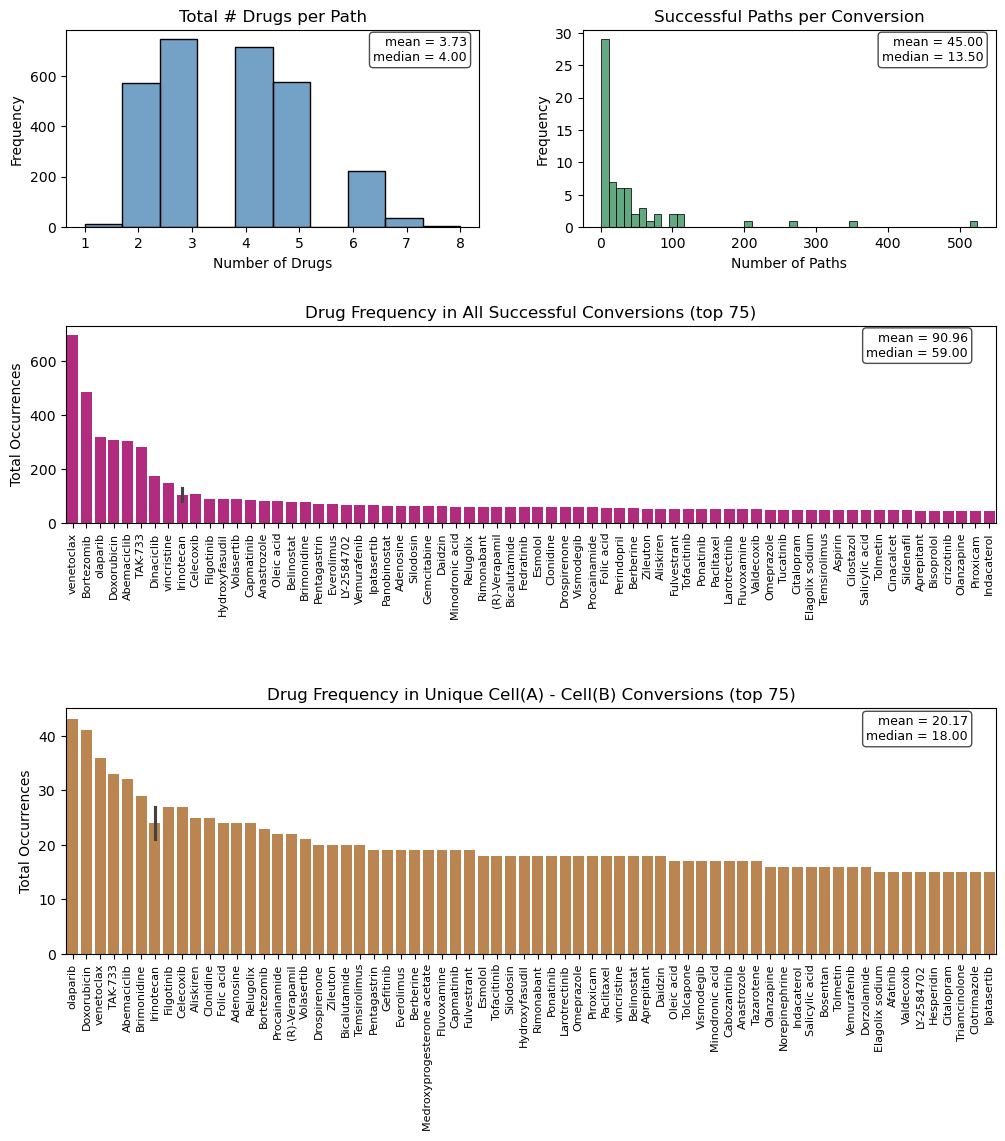

In [24]:
#create the binary drug matrix for each conversion 
drug_matrix = build_conversion_drug_matrix(df)

#plot initial QC for the drug matrix - global metrics
fig, axes = plot_path_and_conversion_stats(drug_matrix, 
                                    figsize=(12,12), 
                                    bins_drugs=10, 
                                    bins_conv=50,
                                    top_n=75,
                                    show=True)

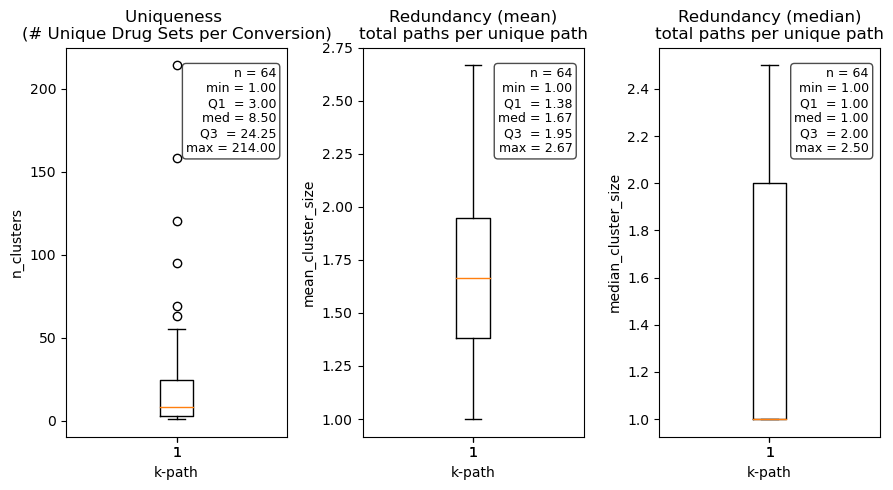

In [25]:
#now we can unsupervised cluster the conversions based on the drug matrix 
summary, detailed = cluster_all_conversions(
    drug_matrix,
    metric="jaccard",
    distance_threshold=0.5,
)

#plot the summary of the clustering results
fig, axes = plot_cluster_summary(
    summary,
    x_label="k-path",
    figsize=(9, 5),
    show=True
)